# 05 — Real data: NGC 4751 MUSE NFM galactic center (high velocity dispersion)

NGC 4751 is a compact, high-mass lenticular/elliptical galaxy observed with VLT/MUSE
in **Narrow Field Mode** (NFM, 0.025"/spaxel — much finer sampling than the 0.2"/spaxel
Wide Field Mode used in notebook 03, though spectrally the two modes are believed to be
the same; see the caveat below). This notebook fits the central Voronoi-binned spectrum,
which — unlike notebook 03's NGC 5102 example — has a **much higher velocity dispersion**
($\sigma \sim 300$-$400$ km/s vs. $\sim 60$ km/s), making it a useful stress test for the
regularization/xlam behavior discussed at the end of this notebook and in
`S0_losvd_recovery_diagnostics.ipynb` / `S1_regularization_demo.ipynb`.

The spectrum (`bin0105sp.spec`) is the central spatial bin, bundled in
`examples/data/muse_n4751/`. It reuses the same stellar templates as notebook 03
(`examples/data/muse/`) — no separate template set is needed.

**Key aspects of real data:**
- Raw flux (counts, not normalized) — `fit_als_continuum=True` handles this
- Galaxy redshift: `zgal = 0.006985` (from the companion pPXF reduction for this galaxy)
- MUSE's per-pixel flux errors are not very reliable, so we override them with a
  uniform S/N-based estimate (`gal_errors=flux/50`), same approach as notebook 03
- Stellar templates: MUSE Library of Stellar Spectra (shared with notebook 03)

**NFM vs. WFM caveat:** this notebook assumes the same wavelength solution as the
bundled WFM data (`wavemin_full=4750.0`, `step=1.25`) since MUSE NFM and WFM share the
same spectrograph/grating and are expected to be spectrally identical. The raw NFM
`.spec` file has one more pixel (3682) than the WFM one (3681) bundled in notebook 03 —
harmless here since `N_PIX` below is read from the file rather than hardcoded, but if
you need precise wavelength calibration for other work, verify against the original
data-reduction pipeline rather than relying on this assumption.

In [1]:
from __future__ import annotations
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

from kinextract import FitConfig, run_spectral_fit
from kinextract.fitting import fit_losvd_gauss_hermite

plt.style.use('kinextract.mplstyle')

# Path to bundled example data (adjust if running from a different location)
DATA_DIR = Path('..') / 'data'
MUSE_DIR = DATA_DIR / 'muse'          # shared templates (same as notebook 03)
N4751_DIR = DATA_DIR / 'muse_n4751'   # this galaxy's spectrum only

# ── To use a different spectrum, change this line ────────────────────────────
SPEC_FILE = N4751_DIR / 'bin0105sp.spec'

## 1. Load and inspect the spectrum

In [2]:
# ── Wavelength grid ───────────────────────────────────────────────────────────
# The .spec file contains integer pixel indices; kinextract reconstructs
# wavelengths as: wave = wavemin_full + (pix - 1) * step
WAVEMIN_FULL = 4750.0    # Å, pixel 1 (assumed same as WFM -- see caveat above)
STEP         = 1.25      # Å / pixel

data = np.loadtxt(SPEC_FILE)
pix, flux, ferr = data[:, 0].astype(int), data[:, 1], data[:, 2] 
N_PIX = len(flux)   # read from the file rather than hardcoded (NFM has one more pixel than WFM)
wavelength = WAVEMIN_FULL + np.arange(N_PIX) * STEP   # observed-frame grid

# MUSE's flux errors are not very reliable, so we can use a simple S/N estimate to set the errors instead
snr = 50.0
ferr = (flux + 1e-6)/ snr

print(f"Spectrum pixels: {len(flux)}")
print(f"Flux range:  {flux.min():.0f} - {flux.max():.0f}  counts")
print(f"Error range: {ferr.min():.0f} - {ferr.max():.0f}  counts")
print(f"Median S/N per pixel: {np.median(flux / ferr):.1f}")

Spectrum pixels: 3682
Flux range:  0 - 1022  counts
Error range: 0 - 20  counts
Median S/N per pixel: 50.0


## 2. Quick-look: raw spectrum over the Ca II fitting region

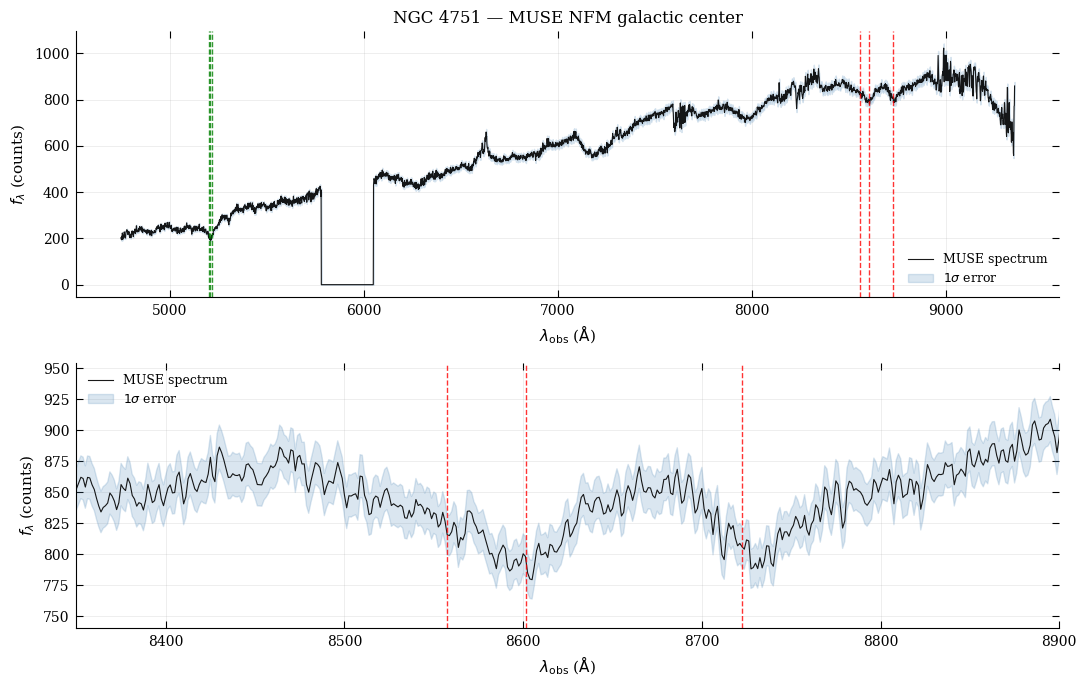

In [3]:
gal_z = 0.006985
CaII_restwaves = np.array([8498.02, 8542.09, 8662.14])
CaII_obswaves = CaII_restwaves * (1 + gal_z)

Mgb_restwaves = np.array([5167.32, 5172.68, 5183.60])
Mgb_obswaves = Mgb_restwaves * (1 + gal_z)

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].plot(wavelength, flux, lw=0.8, color='black', alpha=0.9, label='MUSE spectrum')
ax[0].fill_between(wavelength, flux - ferr, flux + ferr, alpha=0.20, color='steelblue', label=r'$1\sigma$ error')
ax[0].set_xlabel(r'$\lambda_{\mathrm{obs}}$ ($\mathrm{\AA}$)')
ax[0].set_ylabel(r'$f_\lambda$ (counts)')
ax[0].set_title('NGC 4751 — MUSE NFM galactic center')
ax[1].set_xlabel(r'$\lambda_{\mathrm{obs}}$ ($\mathrm{\AA}$)')
ax[1].set_ylabel(r'$f_\lambda$ (counts)')

ax[1].plot(wavelength, flux, lw=0.8, color='black', alpha=0.9, label='MUSE spectrum')
ax[1].fill_between(wavelength, flux - ferr, flux + ferr, alpha=0.20, color='steelblue', label=r'$1\sigma$ error')
ax[1].set_xlim(8350, 8900)
ax[1].set_ylim(0.95 * flux[(wavelength > 8350)&(wavelength < 8900)].min(), 
               1.05 * flux[(wavelength > 8350)&(wavelength < 8900)].max())
ax[0].legend(fontsize=9, framealpha=1.0, facecolor='white').set_zorder(20)
ax[1].legend(fontsize=9, framealpha=1.0, facecolor='white').set_zorder(20)

for obswave in CaII_obswaves:
    ax[0].axvline(obswave, color='red', ls='--', lw=1.0, alpha=0.8)
    ax[1].axvline(obswave, color='red', ls='--', lw=1.0, alpha=0.8)

for obswave in Mgb_obswaves:
    ax[0].axvline(obswave, color='green', ls='--', lw=1.0, alpha=0.8)
    ax[1].axvline(obswave, color='green', ls='--', lw=1.0, alpha=0.8)


plt.tight_layout()
plt.show()

## 3. FitConfig and run

A few settings differ from notebook 03, specifically because of the high dispersion:

- `losvd_vmin`/`losvd_vmax` widened to ±600 km/s (±300 km/s would clip a ~350 km/s LOSVD)
- `sigl = 250.0` (vs. 100.0) so the velocity grid width scales to match
- `xlam_criterion = 'chi2'` instead of `'roughness'`. The `'roughness'` criterion
  compares the LOSVD's curvature to a fixed threshold (0.25) that was tuned for
  narrow LOSVDs; a broad Gaussian's roughness is intrinsically much lower at the same
  grid spacing, so `'roughness'` under-regularizes broad LOSVDs and — as tested for
  this exact bin — can fail outright ("no grid value satisfies roughness <= threshold").
  `'chi2'` is scale-invariant across $\sigma$ and is the package default for this reason.
- `xlam_auto_grid` extended up to $10^7$ (vs. the $10^5$ ceiling used for NGC 5102).
  Empirically, this bin's LOSVD only became single-peaked and stopped showing large
  regularization-driven h3/h4 bias somewhere around xlam $\sim 10^6$ — an order of
  magnitude past where the narrower NGC 5102 example needed to go. See the discussion
  at the end of this notebook.

In [4]:
tmpdir = Path(tempfile.mkdtemp(prefix='kinextract_n4751_'))

cfg = FitConfig(
    template_list_file    = str(MUSE_DIR / 'Tlist'),   # shared templates (see notebook 03)
    template_dir          = str(MUSE_DIR),
    outdir                = str(tmpdir),
    wavemin_full          = WAVEMIN_FULL,  # Å, minimum wavelength of full spectrum (pixel 1)
    step                  = STEP,          # Å / pixel
    wavefitmin            = 8350.0,        # Å  (rest-frame; kinextract applies zgal)
    wavefitmax            = 8900.0,        # Å
    zgal                  = 0.006985,      # redshift estimate from NED
    losvd_vmin            = -1000.0,        # km/s -- widened for the high dispersion
    losvd_vmax            = +1000.0,        # km/s
    fit_als_continuum     = True,
    use_spectrum_errors   = False,         # gal_errors= below takes priority; this is ignored
    xlam_auto             = True,
    xlam_criterion        = 'chi2',        # scale-invariant; see markdown above
    xlam_auto_grid        = (100., 1000., 10000., 100000., 1000000., 10000000.),
    sigl                  = 250.0,         # matches the expected high dispersion
    clean                 = True,
    map_maxiter           = 20000,
    print_every           = 10000,
)

# Pass our SNR-based error estimate directly — overrides whatever is in the file
fit = run_spectral_fit(cfg, gal_file=str(SPEC_FILE), gal_errors=ferr)
st  = fit['state']
out = fit['outputs']
b   = out['b']
gp  = out['gp']
print(f"chi2_red = {out['chi2_red']:.3f}")
print(f"xlam used = {st.xlam}")

[     6.01s] ==== spectral fitting START | ../data/muse_n4751/bin0105sp.spec ====
[     6.01s] wavefit=[8350.0, 8900.0] z=0.006985 sigl=250.0 xlam=300.0
[     6.01s] fit_als_continuum=True prenorm=False
[     6.01s] START build FitState
[     6.01s] START read spectrum
[     6.01s] gal_errors override applied (raw .spec path)
[     6.01s] fit pixels=443 step=1.25
[     6.02s] END   read spectrum (0.01s)
[     6.02s] START apply masks
[     6.03s] Segment emission mask [8350.4–8486.0 Å]: 1 upward-outlier pixels (>3σ above rolling median)
[     6.04s] Segment emission mask [8674.1–8899.1 Å]: 3 upward-outlier pixels (>3σ above rolling median)
[     6.04s] Segment emission pre-mask: 4 additional pixels
[     6.04s] END   apply masks (0.03s)
[     6.04s] START read + interpolate templates
[     6.08s] Template fractional error (pooled median): 0.0077
[     6.08s] END   read + interpolate templates (0.04s)
[     6.08s] LOSVD velocity grid from galaxy.params/config: [-1000.000, 1000.000] km/s

## 4. Gauss-Hermite moments

In [5]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
print(f"V      = {gh['vherm']:+.1f} km/s")
print(f"sigma  = {gh['sherm']:.1f} km/s")
print(f"h3     = {gh['h3']:+.4f}")
print(f"h4     = {gh['h4']:+.4f}")

V      = +150.1 km/s
sigma  = 515.3 km/s
h3     = -0.1157
h4     = -0.1610


## 5. Fit Results

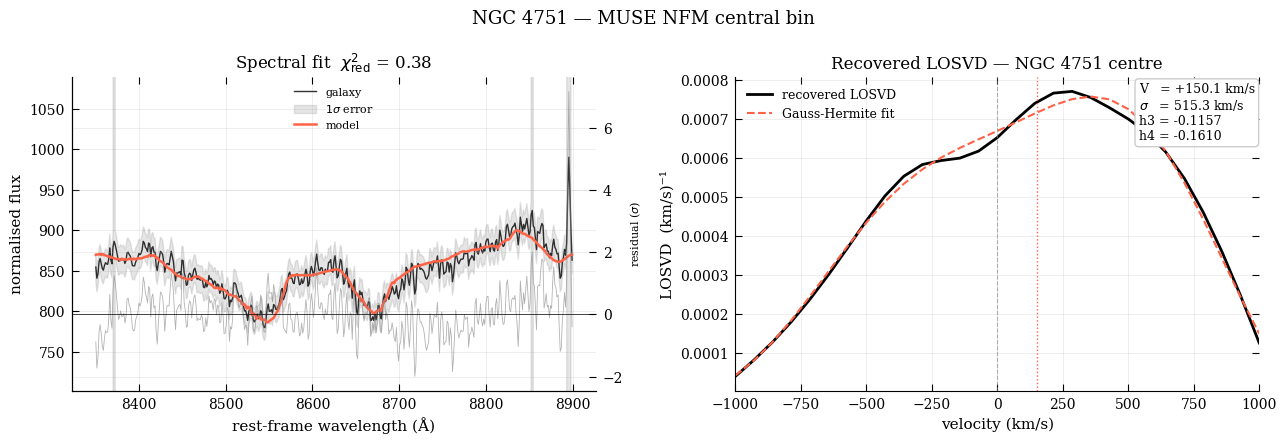

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('NGC 4751 — MUSE NFM central bin', fontsize=13)

# ── Panel 1: spectral fit ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.fill_between(st.x, st.g - st.gerr, st.g + st.gerr, alpha=0.20, color='gray', label=r'$1\sigma$ error')
ax.plot(st.x, gp, lw=1.8, color='tomato', label='model', zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax.set_ylim(0.9*st.g.min(), 1.1*st.g.max())
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.6)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel('rest-frame wavelength (Å)')
ax.set_ylabel('normalised flux')
ax.set_title(r'Spectral fit  $\chi^2_{\rm red}$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# ── Panel 2: LOSVD ────────────────────────────────────────────────────────────
ax = axes[1]
b_norm = b / trapezoid(b, st.xl)
ax.plot(st.xl, b_norm, lw=2.0, color='black', label='recovered LOSVD')
ax.plot(st.xl, gh['model']/trapezoid(gh['model'], st.xl), lw=1.5, color='tomato', ls='--', label='Gauss-Hermite fit')
ax.axvline(gh['vherm'], lw=1.0, color='tomato', ls=':')
ax.axvline(0,           lw=0.8, color='grey',   ls='--', alpha=0.6)
ax.text(0.77, 0.79,
        f"V   = {gh['vherm']:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {gh['sherm']:.1f} km/s\n"
        f"h3 = {gh['h3']:+.4f}\n"
        f"h4 = {gh['h4']:+.4f}",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title('Recovered LOSVD — NGC 4751 centre')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()

## 6. Error estimation

Uncertainty on the LOSVD is estimated two ways:

- **Laplace covariance**: Gaussian approximation at the MAP solution — fast, analytical, reliable for Gaussian LOSVDs.
- **Residual bootstrap**: Resamples fit residuals to generate synthetic spectra and re-fits each → non-parametric; preferred for publication uncertainties.

In [ ]:
from kinextract import LOSVDErrorEstimator

# N_BOOT is lower here than in notebooks 02-04 (which use 50): each replicate on
# this bin costs ~18s serially (vs. a few seconds for the lower-sigma NGC 5102
# bins), since a broader LOSVD needs a larger xlam and the ALS continuum refit per
# replicate is correspondingly more expensive. Increase to >=200 for publication,
# and consider n_jobs>1 (see the Greatlakes/SLURM discussion in the top-level docs)
# if running many bins like this one.
N_BOOT = 20

est     = LOSVDErrorEstimator(fit, cfg)
laplace = est.laplace_covariance()
boot    = est.residual_bootstrap(n_bootstrap=N_BOOT, n_jobs=1)
summary = est.summarize(laplace_result=laplace, bootstrap_result=boot)

gh_map = summary['gh_map']
gh_err = summary.get('gh_err_recommended', {})
print("Kinematic moments (bootstrap uncertainties):")
for label, mkey, ekey in [('V', 'vherm', 'gh_vherm'), ('σ', 'sherm', 'gh_sherm'),
                           ('h3', 'h3', 'gh_h3'), ('h4', 'h4', 'gh_h4')]:
    val = gh_map.get(mkey)
    err = gh_err.get(ekey)
    if val is not None:
        err_str = f' ± {err:.2f}' if err is not None else ''
        unit = ' km/s' if label in ('V', 'σ') else ''
        print(f'  {label:5s} = {val:+.2f}{unit}{err_str}')

[LOSVDErrors] Computing Hessian...
[LOSVDErrors] Using JAX gradient-backed Hessian FD (CPU)
[LOSVDErrors] Laplace covariance done in 0.5s. Hessian PD (free params): True. Pinned: 0/29 LOSVD bins, 31/35 template weights. Max projected |grad|: 11.1
[LOSVDErrors] Starting residual bootstrap (n=20, block=1, jobs=1)...
[   354.47s] Ca II mask shift: +9.577 Å  (als_mask_center_shift_A → 14.963 Å)
[   354.47s] ALS absorption-clean iter 1: sigma=1.078, rejected=0, base_pixels=400
[   354.47s] ALS init: lam=1.000e+07 p=0.05 median=819.5 base_pixels=400 line_mask_pixels=38
[   354.47s] ALS outer iteration 1/4
[   354.47s]   protecting Ca II [8501.6, 8524.3] npix=19
[   354.47s]   protecting Ca II [8545.6, 8568.5] npix=18
[   354.47s]   protecting Ca II [8665.5, 8688.7] npix=19
[   354.47s] Cleaning protection: 56 pixels
[   354.47s] START MAP clean iter 1


/var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/ipykernel_99498/248528002.py:12: RuntimeWarning: Laplace covariance: the largest projected gradient component at the MAP solution is 11.1, above grad_warn_threshold=0.05. This suggests the MAP optimization did not fully converge, which can make the Hessian indefinite and the resulting error bars unreliable (some may be silently near-zero). Consider tightening map_ftol/map_gtol or enabling use_jax_objective before re-fitting.
  laplace = est.laplace_covariance()


[   368.80s] END   MAP clean iter 1 (14.33s)
[   368.80s] Clean converged after 1 iter.
[   368.80s] ALS absorption-clean iter 1: sigma=0.7088, rejected=0, base_pixels=400
[   368.80s]   ALS update: lam=1.000e+07 p=0.05 delta=0.01382 base_pixels=400 line_mask_pixels=38
[   368.80s]   ALS continuum median fractional change = 0.01382
[   368.81s] ALS outer iteration 2/4
[   368.81s] START MAP optimize ALS outer 2
[   382.79s] END   MAP optimize ALS outer 2 (13.98s)
[   382.79s] ALS absorption-clean iter 1: sigma=0.6486, rejected=0, base_pixels=400
[   382.79s]   ALS update: lam=1.000e+07 p=0.05 delta=0.01328 base_pixels=400 line_mask_pixels=38
[   382.79s]   ALS continuum median fractional change = 0.01328
[   382.79s] ALS outer iteration 3/4
[   382.79s] START MAP optimize ALS outer 3
[   390.39s] END   MAP optimize ALS outer 3 (7.60s)
[   390.40s] ALS absorption-clean iter 1: sigma=0.6423, rejected=0, base_pixels=400
[   390.40s]   ALS update: lam=1.000e+07 p=0.05 delta=0.01357 base_pi

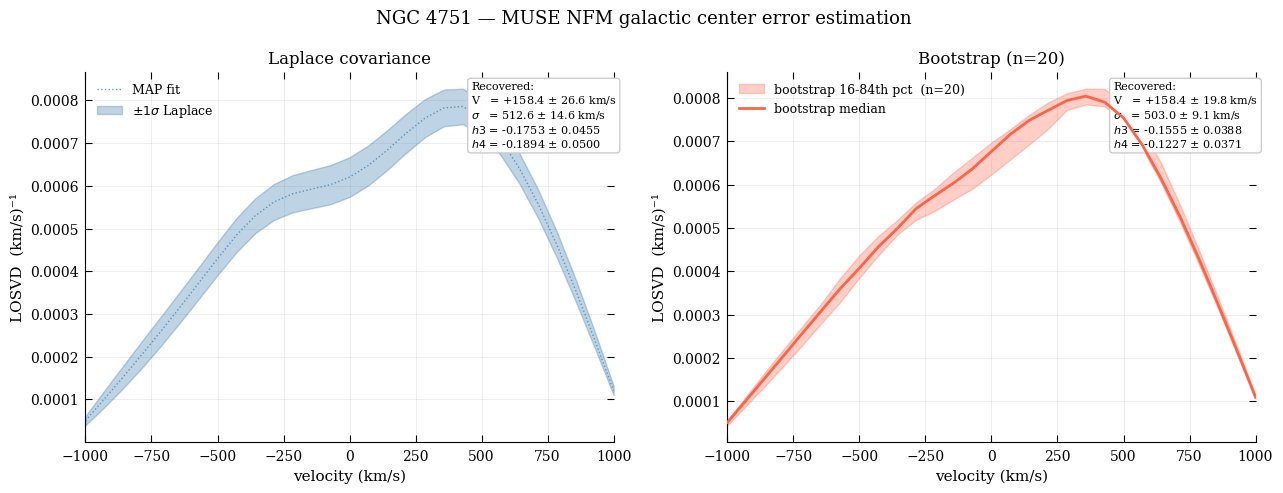

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('NGC 4751 — MUSE NFM galactic center error estimation', fontsize=13)

b_trap = trapezoid(b, st.xl)
b_map  = b / b_trap

bs       = np.array(boot['b_samples'])
bs_traps = np.array([trapezoid(s, st.xl) for s in bs])[:, np.newaxis]
bs       = bs / bs_traps
b_median = np.median(bs, axis=0)
b_lo     = np.maximum(np.percentile(bs, 16, axis=0), 0.0)
b_hi     = np.percentile(bs, 84, axis=0)
gh_med   = fit_losvd_gauss_hermite(st.xl, b_median, fit_h3h4=True)

# Panel 1: Laplace
ax = axes[0]
b_sig  = laplace['b_err'] / b_trap
b_lo_l = np.maximum(b_map - b_sig, 0.0)   # LOSVD >= 0 everywhere
ax.plot(st.xl, b_map, lw=1.0, ls=':', color='steelblue', alpha=0.8, label='MAP fit')
ax.fill_between(st.xl, b_lo_l, b_map + b_sig,
                alpha=0.35, color='steelblue', label=r'$\pm 1\sigma$ Laplace')

ax.text(0.73, 0.79,
        "Recovered:\n"
        fr"V   = {gh_map['vherm']:+.1f} $\pm$ {laplace['gh_err']['gh_vherm']:.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_map['sherm']:.1f} $\pm$ {laplace['gh_err']['gh_sherm']:.1f}" + " km/s\n"
        fr"$h3$ = {gh_map['h3']:+.4f} $\pm$ {laplace['gh_err']['gh_h3']:.4f}" + "\n"
        fr"$h4$ = {gh_map['h4']:+.4f} $\pm$ {laplace['gh_err']['gh_h4']:.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title('Laplace covariance')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

# Panel 2: Bootstrap
ax = axes[1]
ax.fill_between(st.xl, b_lo, b_hi, alpha=0.30, color='tomato',
                label=f'bootstrap 16-84th pct  (n={N_BOOT})')
ax.plot(st.xl, b_median, lw=2.0, color='tomato', zorder=5, label='bootstrap median')


ax.text(0.73, 0.79,
        f"Recovered:\n"
        fr"V   = {gh_med['vherm']:+.1f} $\pm$ {gh_err.get('gh_vherm', float('nan')):.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_med['sherm']:.1f} $\pm$ {gh_err.get('gh_sherm', float('nan')):.1f}" + " km/s\n"
        fr"$h3$ = {gh_med['h3']:+.4f} $\pm$ {gh_err.get('gh_h3', float('nan')):.4f}" + "\n"
        fr"$h4$ = {gh_med['h4']:+.4f} $\pm$ {gh_err.get('gh_h4', float('nan')):.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title(f'Bootstrap (n={N_BOOT})')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()

## 7. Built-in diagnostic plots

`kinextract.plotting` ships ready-made diagnostic plots so you don't have to
write custom matplotlib code for routine quick-looks:

- `plot_fit(fit)` / `plot_losvd(fit)` — same idea as the panels built by hand
  in Section 5, in one line each.
- `plot_als_continuum(fit, cfg)` — specifically for `fit_als_continuum=True`
  fits like this one. Shows the data, model, and ALS continuum baseline; a
  continuum-normalized view; and residuals, with detected emission/absorption
  regions shaded and labeled. Passing `cfg` (rather than leaving it out) adds
  labels for the specific lines this fit's masking actually detected, on top
  of the curated reference-line ticks shown either way.

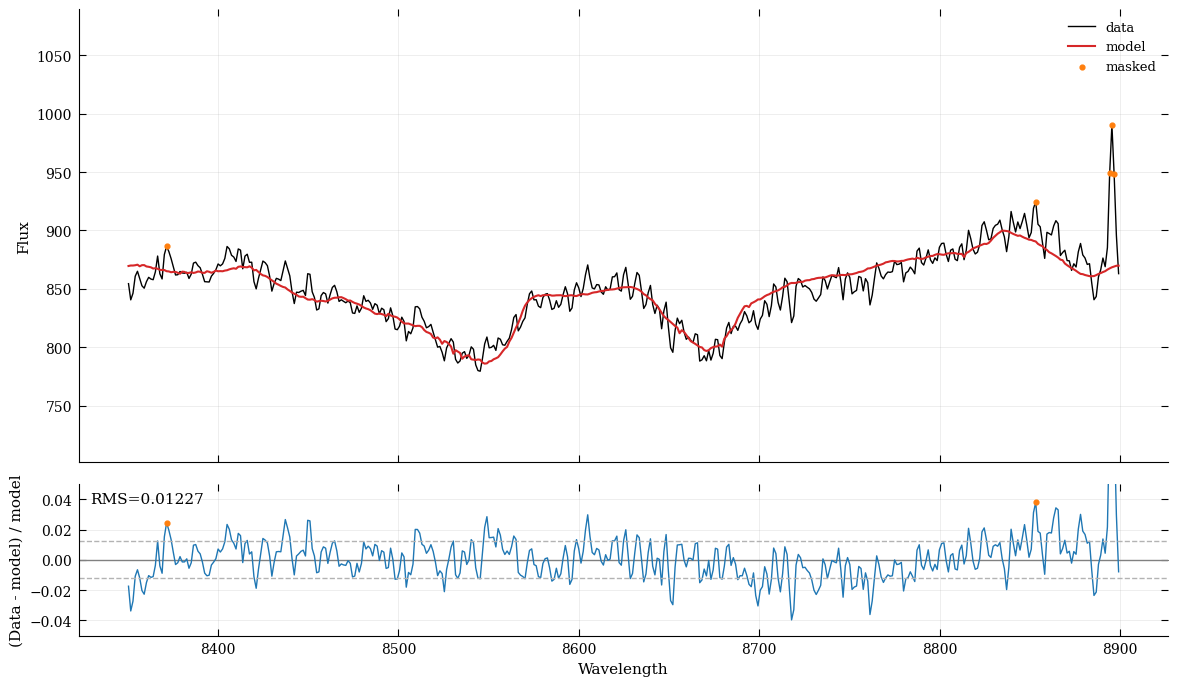

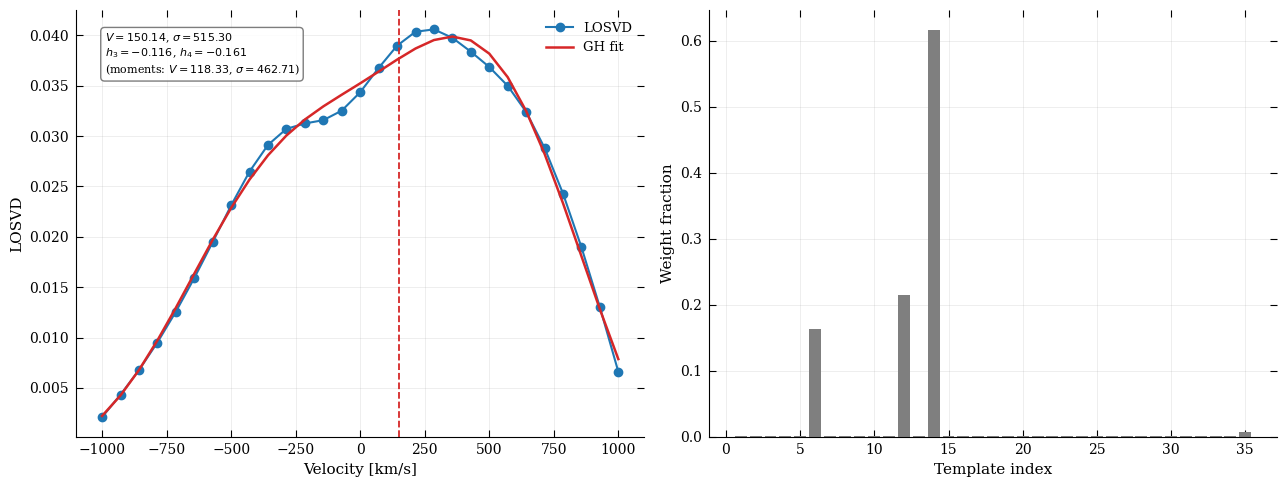

vherm=150.1417  sherm=515.3004  h3=-0.1157  h4=-0.1610  success=True


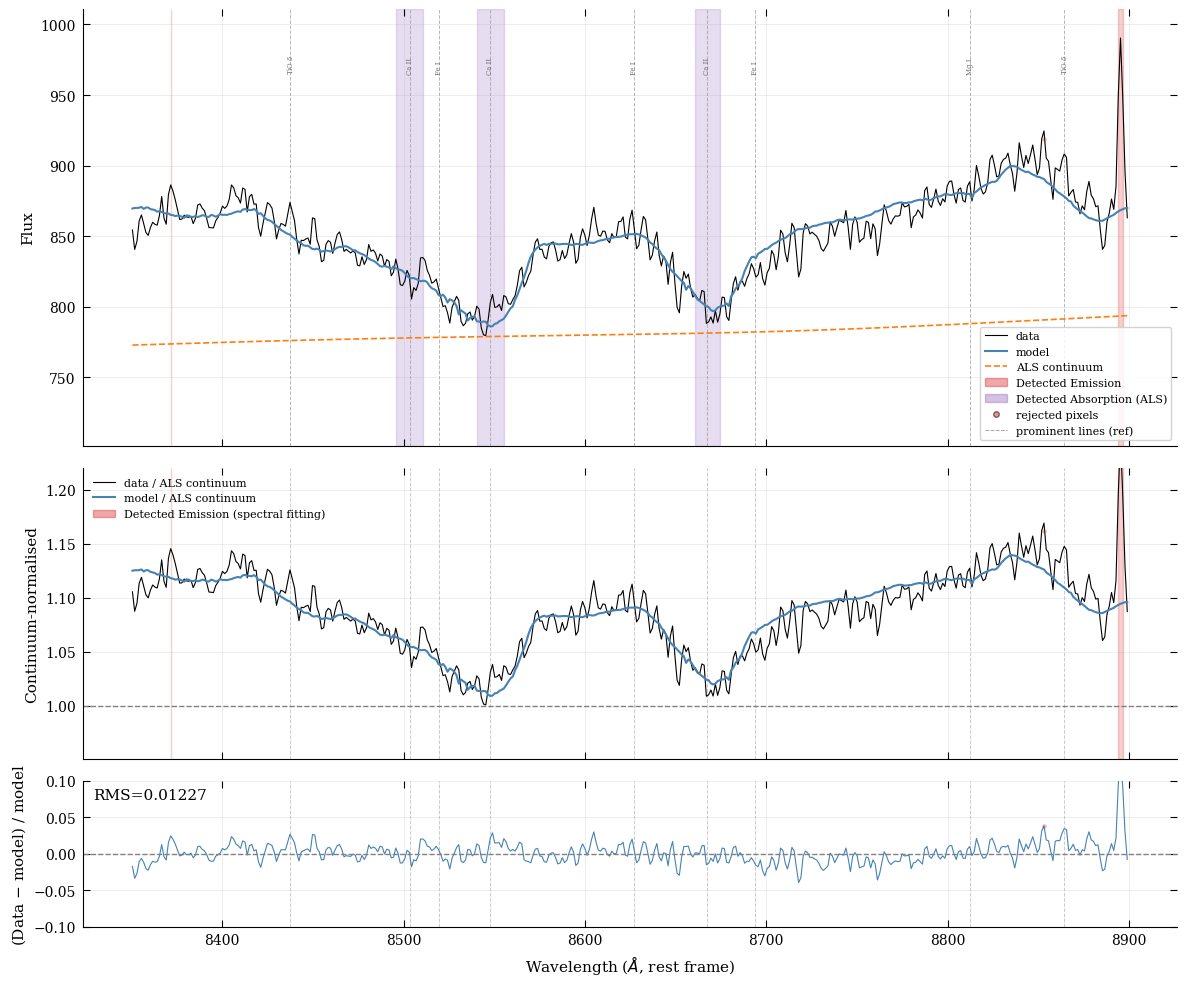

In [7]:
from kinextract.plotting import plot_fit, plot_losvd, plot_als_continuum

plot_fit(fit)
plot_losvd(fit)
plot_als_continuum(fit, cfg)

## 8. Why high-$\sigma$ LOSVDs need much more regularization

This bin is a good illustration of a real, general limitation: **the same absolute
`xlam` value smooths a broad LOSVD far less, relatively, than a narrow one.** A
Gaussian's curvature (what the roughness penalty actually measures) scales roughly as
$1/\sigma^2$, so a $\sigma=350$ km/s LOSVD is intrinsically ~10x "smoother" than a
$\sigma=100$ km/s one at the same grid spacing, for the same noise level. Left at the
`xlam_auto_grid` ceiling used for NGC 5102 ($10^5$), this bin's recovered LOSVD is
still double-peaked with large, almost certainly spurious h3/h4. Sweeping `xlam` higher
shows the LOSVD only becomes single-peaked, with h3/h4 relaxing toward more plausible
values, around $10^6$-$10^7$ — a full 1-2 orders of magnitude past where NGC 5102 needed.

This is exactly why the config above uses `xlam_criterion='chi2'` (scale-invariant) and
an extended `xlam_auto_grid` rather than the notebook-03 defaults. The cell below
reproduces the sweep so you can see the transition directly.

In [8]:
import dataclasses
from kinextract.fitting import compute_losvd_roughness, compute_losvd_n_peaks

sweep_results = []
for xlam_fixed in [1e5, 3e5, 1e6, 3e6, 1e7, 3e7, 1e8]:
    cfg_sweep = dataclasses.replace(cfg, xlam_auto=False, xlam=xlam_fixed)
    fit_sweep = run_spectral_fit(cfg_sweep, gal_file=str(SPEC_FILE), gal_errors=ferr)
    b_sweep = fit_sweep['outputs']['b']
    gh_sweep = fit_losvd_gauss_hermite(fit_sweep['state'].xl, b_sweep, fit_h3h4=True)
    sweep_results.append(dict(
        xlam=xlam_fixed,
        chi2_red=fit_sweep['outputs']['chi2_red'],
        roughness=compute_losvd_roughness(b_sweep),
        npeaks=compute_losvd_n_peaks(b_sweep),
        gh=gh_sweep,
    ))
    r = sweep_results[-1]
    print(f"xlam={r['xlam']:>10.0f}  chi2_red={r['chi2_red']:.3f}  roughness={r['roughness']:.4f}  "
          f"npeaks={r['npeaks']}  V={r['gh']['vherm']:+.1f}  sigma={r['gh']['sherm']:.1f}  "
          f"h3={r['gh']['h3']:+.3f}  h4={r['gh']['h4']:+.3f}")

[    83.88s] ==== spectral fitting START | ../data/muse_n4751/bin0105sp.spec ====
[    83.88s] wavefit=[8350.0, 8900.0] z=0.006985 sigl=250.0 xlam=100000.0
[    83.88s] fit_als_continuum=True prenorm=False
[    83.88s] START build FitState
[    83.88s] START read spectrum
[    83.88s] gal_errors override applied (raw .spec path)
[    83.88s] fit pixels=443 step=1.25
[    83.88s] END   read spectrum (0.00s)
[    83.88s] START apply masks
[    83.89s] Segment emission mask [8350.4–8486.0 Å]: 1 upward-outlier pixels (>3σ above rolling median)
[    83.89s] Segment emission mask [8674.1–8899.1 Å]: 3 upward-outlier pixels (>3σ above rolling median)
[    83.89s] Segment emission pre-mask: 4 additional pixels
[    83.90s] END   apply masks (0.01s)
[    83.90s] START read + interpolate templates
[    83.93s] Template fractional error (pooled median): 0.0077
[    83.93s] END   read + interpolate templates (0.03s)
[    83.93s] LOSVD velocity grid from galaxy.params/config: [-1000.000, 1000.000] k

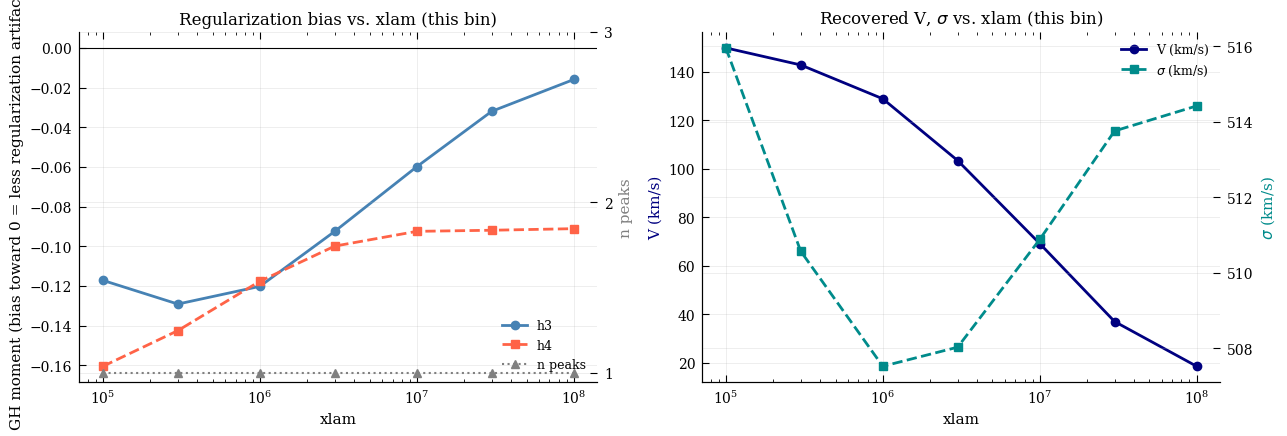

Auto-selected xlam for this bin: 100000
Note how far past 1e5 (the NGC 5102 ceiling) this bin needs to go before h3/h4 stabilize.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

xlams_sw = [r['xlam'] for r in sweep_results]

ax = axes[0]
ax2 = ax.twinx()
ax.semilogx(xlams_sw, [r['gh']['h3'] for r in sweep_results], 'o-', color='steelblue', lw=2, label='h3')
ax.semilogx(xlams_sw, [r['gh']['h4'] for r in sweep_results], 's--', color='tomato', lw=2, label='h4')
ax2.semilogx(xlams_sw, [r['npeaks'] for r in sweep_results], '^:', color='grey', lw=1.5, label='n peaks')
ax.axhline(0, lw=0.8, color='black')
ax.set_xlabel('xlam'); ax.set_ylabel('GH moment (bias toward 0 = less regularization artifact)')
ax2.set_ylabel('n peaks', color='grey')
ax2.set_yticks([1, 2, 3])
l1, n1 = ax.get_legend_handles_labels(); l2, n2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, n1+n2, fontsize=9).set_zorder(20)
ax.set_title('Regularization bias vs. xlam (this bin)')

ax = axes[1]
ax2 = ax.twinx()
ax.semilogx(xlams_sw, [r['gh']['vherm'] for r in sweep_results], 'o-', color='navy', lw=2, label='V (km/s)')
ax2.semilogx(xlams_sw, [r['gh']['sherm'] for r in sweep_results], 's--', color='darkcyan', lw=2, label=r'$\sigma$ (km/s)')
ax.set_xlabel('xlam'); ax.set_ylabel('V (km/s)', color='navy')
ax2.set_ylabel(r'$\sigma$ (km/s)', color='darkcyan')
l1, n1 = ax.get_legend_handles_labels(); l2, n2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, n1+n2, fontsize=9).set_zorder(20)
ax.set_title('Recovered V, $\\sigma$ vs. xlam (this bin)')

plt.tight_layout()
plt.show()

print(f"Auto-selected xlam for this bin: {st.xlam:.0f}")
print("Note how far past 1e5 (the NGC 5102 ceiling) this bin needs to go before h3/h4 stabilize.")